In [1]:
# Use this in Colab session
#%cd /content
#!rm -rf rainfall_kf
#
#!git clone https://github.com/Felix-Schwer/rainfall_kf.git
#%cd rainfall_kf

# Use this on local machine
%cd C:/Users/fschwer/Documents/CEE 261D Data Assimilation/Final Project/rainfall_kf

!pip install -e .

C:\Users\fschwer\Documents\CEE 261D Data Assimilation\Final Project\rainfall_kf
Obtaining file:///C:/Users/fschwer/Documents/CEE%20261D%20Data%20Assimilation/Final%20Project/rainfall_kf
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'done'
  Preparing editable metadata (pyproject.toml): started
  Preparing editable metadata (pyproject.toml): finished with status 'done'
  Building editable for rainfall_kf (pyproject.toml): started
  Building editable for rainfall_kf (pyproject.toml): finished with status 'done'
  Created wheel for rainfall_kf: filename=rainfall_kf-0.1.0-0.editable-py3-none-any.whl size=2787 sha256=a9e83bac0d2f2ae8f7ab3601fbe3674c44b193a94df8d60a9dc648de70c86b9b
  St

In [2]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# have to cd on local machine
%cd C:/Users/fschwer/Documents/CEE 261D Data Assimilation/Final Project/rainfall_kf/notebooks

prism_ds = xr.open_dataset('../data/prism_basin_means.nc')
gpm_ds = xr.open_dataset('../data/gpm_basin_means.nc')
et_ds = xr.open_dataset('../data/et_basin_means.nc')
temp_ds = xr.open_dataset('../data/temp_basin_means.nc')

from rainfall_kf.models.hbvedu import processed_inputs_fromds
et_ds, (monthly_et, monthly_temp) = processed_inputs_fromds(et_ds, temp_ds, starttime='2000-01-01', endtime='2020-12-31')


C:\Users\fschwer\Documents\CEE 261D Data Assimilation\Final Project\rainfall_kf\notebooks


In [3]:
stations_in_basin = {
    "18040001": ["11273400"], # Middle San Joaquin-Lower Chowchilla
    "18040002": ["11274550"], # Lower San Joaquin River
    "18040003": ["11303500"], # San Joaquin Delta
    "18040006": [], # Upper San Joaquin
    "18040007": [], # Fresno River
    "18040008": ["11272500"],# Upper Merced
    "18040009": ["11290000"], # Upper Tuolumne
    "18040010": ["11303000"], # Upper Stanislaus
    "18040011": [], # Upper Calaveras
    "18040012": ["11325500"], # Upper Mokelumne
    "18040013": [], # Upper Cosumnes
    "18040014": ["11255575"] # Panoche-San Luis Reservoir
}

stream_ds = xr.open_dataset('../data/streamflow.nc')

In [4]:
basin_id = "18040009"
station_id = stations_in_basin[basin_id][0]
start_time = stream_ds.sel(site=station_id).continuous_start.values
end_time = stream_ds.sel(site=station_id).continuous_end.values

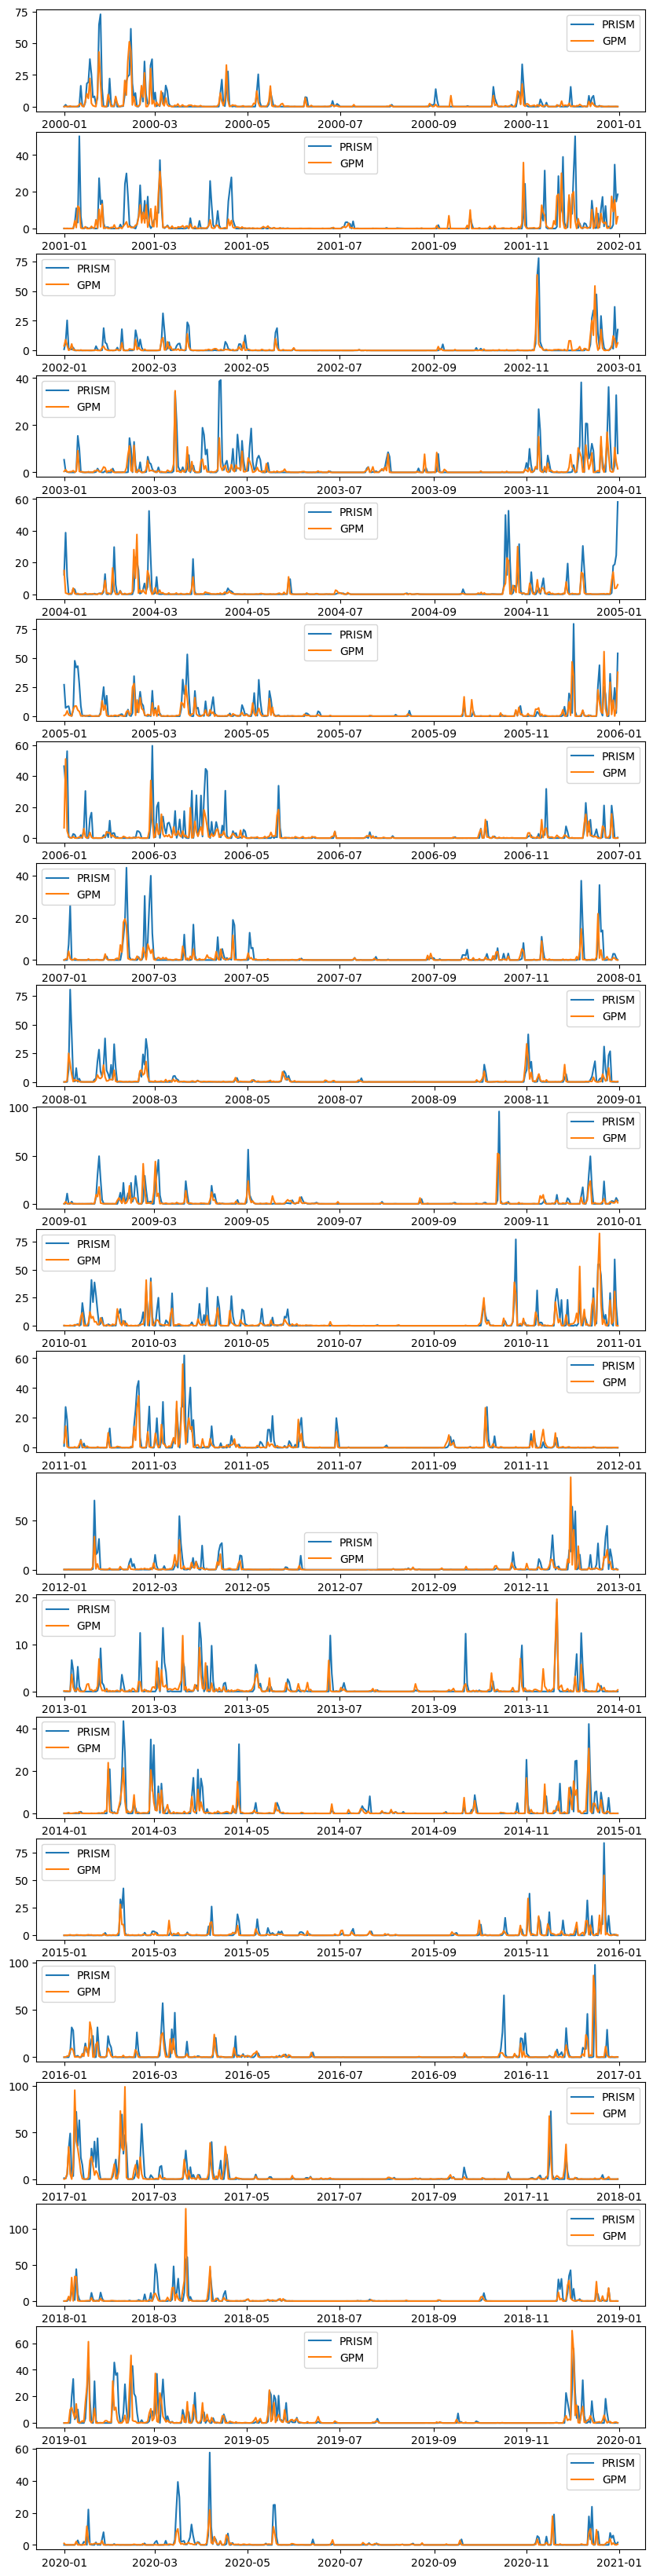

In [17]:
date_range = pd.date_range(start_time, end_time, freq='D')
fig, axes = plt.subplots(date_range.year.max()-date_range.year.min()+1, 1, figsize=(10, 2*(date_range.year.max()-date_range.year.min()+1)))
for i,year in enumerate(range(date_range.year.min(), date_range.year.max() + 1)):
    year_range = pd.date_range(f'{year}-01-01', f'{year}-12-31', freq='D')
    axes[i].plot(year_range, prism_ds.precipitation.sel(basin=basin_id, time=year_range), label='PRISM')
    axes[i].plot(year_range, gpm_ds.precipitation.sel(basin=basin_id, time=year_range), label='GPM')
    axes[i].legend()